# Conversion of A-mode to M-mode Stimulation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
NUM_DEPTH_SAMPLES = 1000

NUM_TIME_SAMPLES = 500
TIME_STEP = 1

print("Depth samples:", NUM_DEPTH_SAMPLES)
print("Time samples:", NUM_TIME_SAMPLES)

Depth samples: 1000
Time samples: 500


In [3]:
depth = np.arange(NUM_DEPTH_SAMPLES)
a_mode = np.zeros(NUM_DEPTH_SAMPLES)

a_mode += 0.05 * np.random.randn(NUM_DEPTH_SAMPLES)

artery_depth = 400

for d in range(NUM_DEPTH_SAMPLES):
    distance = abs(d - artery_depth)

    if distance < 8:
        a_mode[d] += np.exp(-(distance ** 2) / 8)


a_mode = np.abs(a_mode)
a_mode = a_mode / np.max(a_mode)

print("A-mode array shape:", a_mode.shape)

A-mode array shape: (1000,)


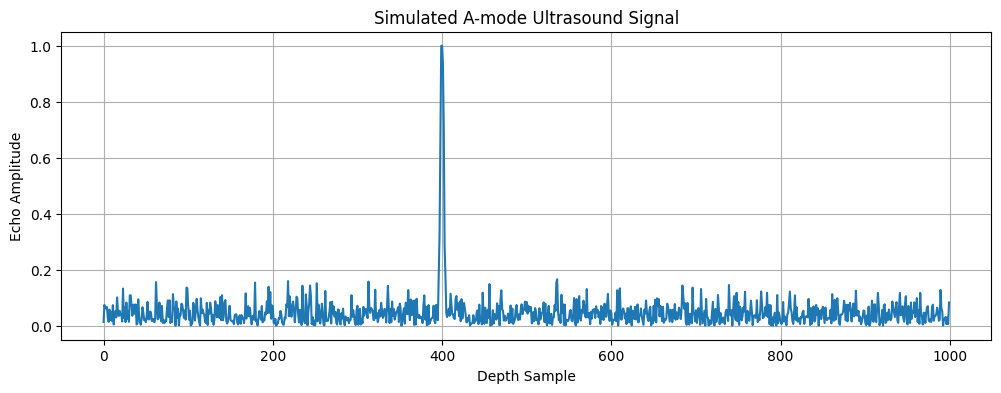

In [4]:
plt.figure(figsize=(12, 4))

plt.plot(depth, a_mode)

plt.xlabel("Depth Sample")
plt.ylabel("Echo Amplitude")
plt.title("Simulated A-mode Ultrasound Signal")

plt.grid()
plt.show()

In [5]:
m_mode = np.zeros(
    (NUM_DEPTH_SAMPLES, NUM_TIME_SAMPLES)
)

print("M-mode matrix shape:", m_mode.shape)

M-mode matrix shape: (1000, 500)


In [6]:
for t in range(NUM_TIME_SAMPLES):

    artery_depth = 400 + int(
        20 * np.sin(2 * np.pi * t / 100)
    )

    current_a_mode = 0.05 * np.random.randn(
        NUM_DEPTH_SAMPLES
    )

    for d in range(NUM_DEPTH_SAMPLES):

        distance = abs(d - artery_depth)

        if distance < 8:
            current_a_mode[d] += np.exp(
                -(distance ** 2) / 8
            )

    current_a_mode = np.abs(current_a_mode)

    max_value = np.max(current_a_mode)

    if max_value > 0:
        current_a_mode /= max_value

    m_mode[:, t] = current_a_mode

print("M-mode generation completed.")

M-mode generation completed.


In [7]:
print("M-mode shape:", m_mode.shape)
print("Minimum value:", m_mode.min())
print("Maximum value:", m_mode.max())

M-mode shape: (1000, 500)
Minimum value: 2.2962322337086306e-07
Maximum value: 1.0


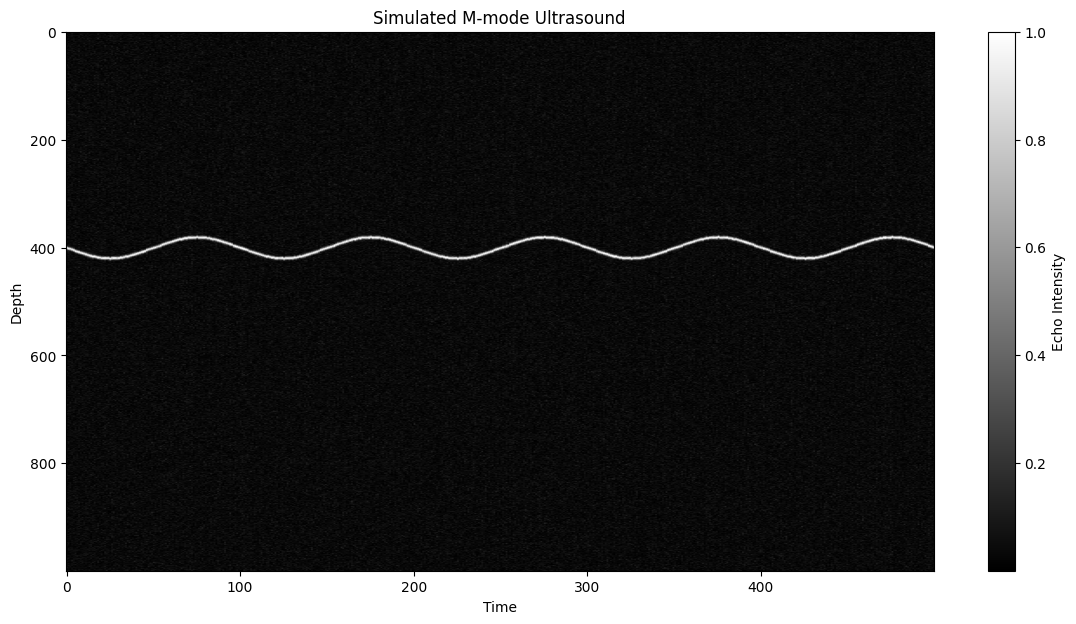

In [8]:
plt.figure(figsize=(14, 7))

plt.imshow(
    m_mode,
    cmap="gray",
    aspect="auto",
    origin="upper"
)

plt.xlabel("Time")
plt.ylabel("Depth")
plt.title("Simulated M-mode Ultrasound")

plt.colorbar(label="Echo Intensity")

plt.show()

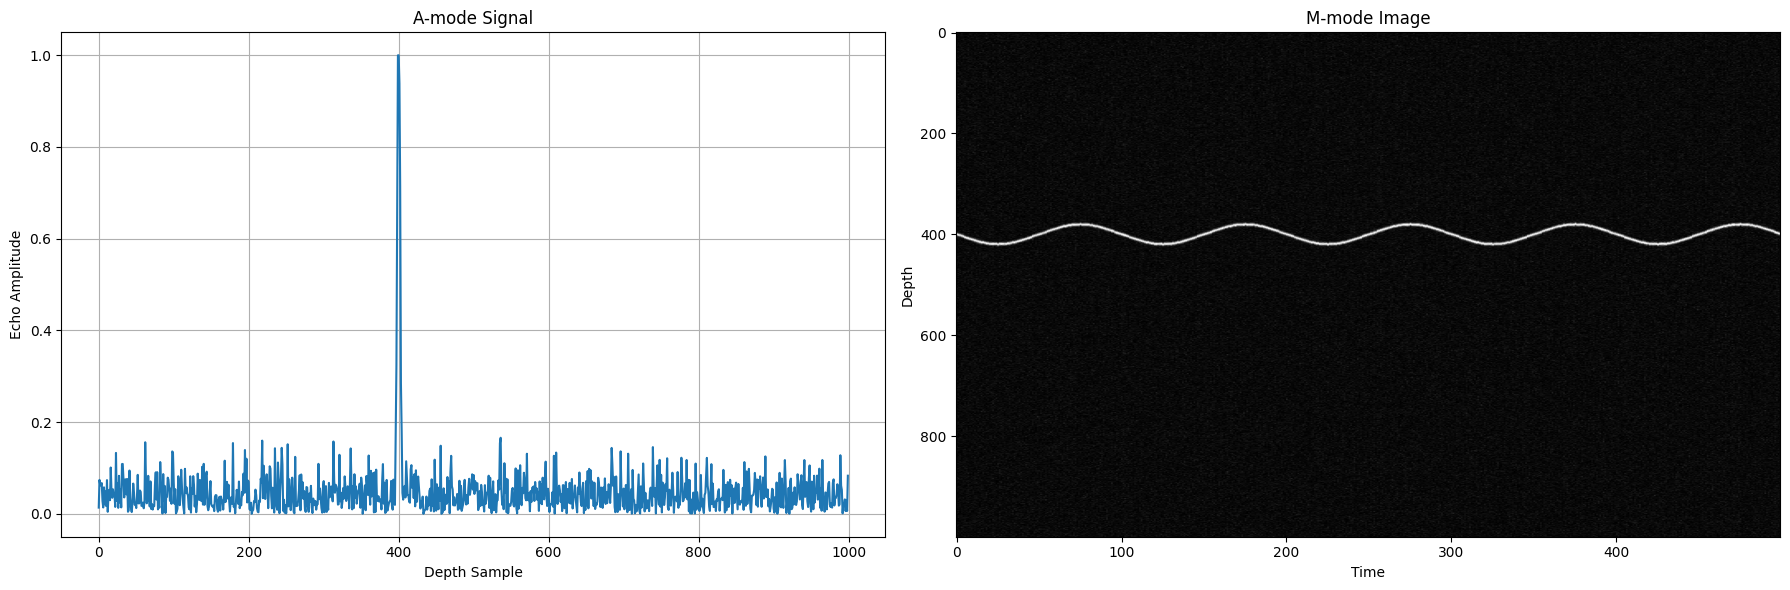

In [9]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 6)
)

# A-mode
axes[0].plot(depth, a_mode)

axes[0].set_xlabel("Depth Sample")
axes[0].set_ylabel("Echo Amplitude")
axes[0].set_title("A-mode Signal")
axes[0].grid()

# M-mode
axes[1].imshow(
    m_mode,
    cmap="gray",
    aspect="auto",
    origin="upper"
)

axes[1].set_xlabel("Time")
axes[1].set_ylabel("Depth")
axes[1].set_title("M-mode Image")

plt.tight_layout()
plt.show()

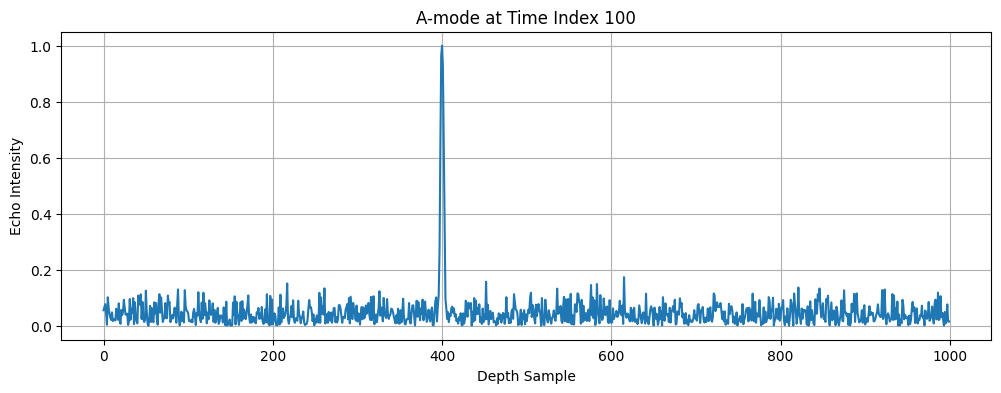

In [10]:
# Select a particular time instant
time_index = 100

extracted_a_mode = m_mode[:, time_index]

plt.figure(figsize=(12, 4))

plt.plot(depth, extracted_a_mode)

plt.xlabel("Depth Sample")
plt.ylabel("Echo Intensity")
plt.title(f"A-mode at Time Index {time_index}")

plt.grid()
plt.show()

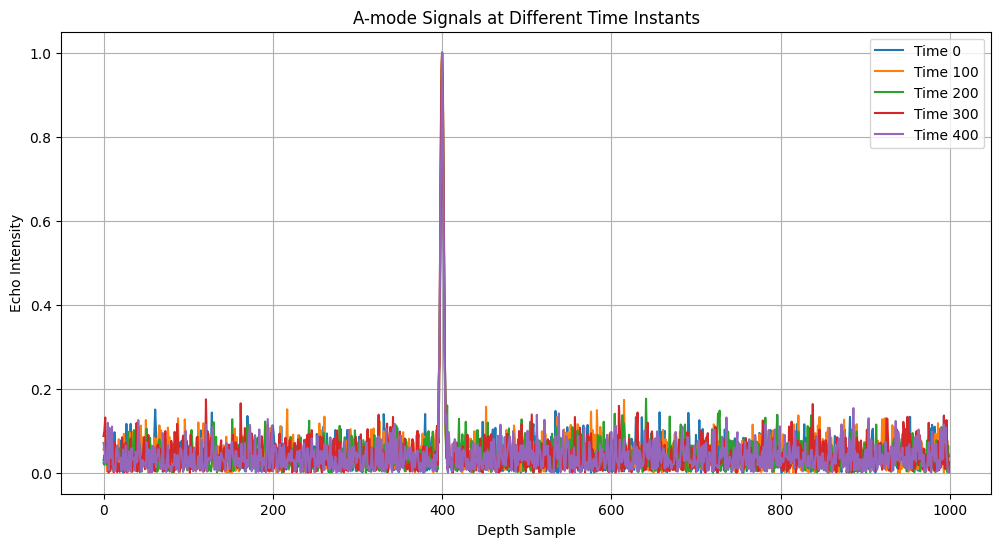

In [11]:
time_indices = [0, 100, 200, 300, 400]

plt.figure(figsize=(12, 6))

for t in time_indices:
    plt.plot(
        depth,
        m_mode[:, t],
        label=f"Time {t}"
    )

plt.xlabel("Depth Sample")
plt.ylabel("Echo Intensity")
plt.title("A-mode Signals at Different Time Instants")

plt.legend()
plt.grid()
plt.show()

In [14]:
print("A-MODE → M-MODE SIMULATION")


print("A-mode size:", len(a_mode))
print("Number of A-mode scans:", NUM_TIME_SAMPLES)
print("M-mode dimensions:", m_mode.shape)

print("\nInterpretation:")
print("1000 samples = Depth dimension")
print("500 scans    = Time dimension")
print("M-mode       = Depth × Time")

A-MODE → M-MODE SIMULATION
A-mode size: 1000
Number of A-mode scans: 500
M-mode dimensions: (1000, 500)

Interpretation:
1000 samples = Depth dimension
500 scans    = Time dimension
M-mode       = Depth × Time
